# Cross-Architecture Transfer on the ArchPower Event Dataset

User interface for cross-arch transfer. Trains a model on **all** samples of one architecture (BOOM or XS) and evaluates on **all** samples of the other. All heavy lifting lives in `src/event_cross_arch.py`; this notebook configures, calls, and displays results.

The event-only dataset is architecture-normalized by resource functions, so both arches share the same 81 event features -- making the experiment meaningful. Feature/label normalization uses source-arch statistics only.

Run from the `script/` directory. Outputs land in `output/cross_<MODEL>_<TRAIN>_to_<TEST>/` at the repo root.

In [1]:
import os, sys
sys.path.insert(0, os.path.join("..", "src"))

import matplotlib.pyplot as plt

from event_utils import COMP_NAMES, compute_metrics
from event_attention import EVENT_NAMES
import event_cross_arch as cross

In [23]:
# Model family: "gbdt" (XGBoost) or "linear" (Ridge)
MODEL_KIND = "gbdt"

TRAIN_ARCH = "BOOM"
TEST_ARCH = "XS"
SEED = 42

# GBDT hyperparameters
N_ESTIMATORS = 100
MAX_DEPTH = 6
LEARNING_RATE = 0.3

# Ridge hyperparameter
ALPHA = 1.0

OUT_DIR = os.path.join("..", "output",
                       f"cross_{MODEL_KIND}_{TRAIN_ARCH}_to_{TEST_ARCH}")
os.makedirs(OUT_DIR, exist_ok=True)

if TRAIN_ARCH == TEST_ARCH:
    print(f"[warn] TRAIN_ARCH == TEST_ARCH ({TRAIN_ARCH}); "
          f"running as same-arch sanity check.")

## 1. Load and normalize both arches

Source-arch statistics are applied to the target arch. The target is fully held out -- no samples leak into training.

In [24]:
data = cross.build_data(TRAIN_ARCH, TEST_ARCH)
n_train = data["X_train"].shape[0]
n_test = data["X_test"].shape[0]
n_targets = data["y_train"].shape[1]
print(f"source={TRAIN_ARCH}  target={TEST_ARCH}")
print(f"train: {n_train}  test: {n_test}  "
      f"features: {data['X_train'].shape[1]}  targets: {n_targets}")

source=BOOM  target=XS
train: 120  test: 80  features: 81  targets: 12


## 2. Train on source arch

For `gbdt`, fits 12 independent XGBRegressor models (one per power component). For `linear`, fits a single multi-output Ridge regressor.

In [25]:
if MODEL_KIND == "gbdt":
    models = cross.train_gbdt(
        data,
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        learning_rate=LEARNING_RATE,
        seed=SEED,
        feature_names=EVENT_NAMES,
    )
    pred = cross.predict_gbdt(models, data)
    n_params = "N/A (tree ensemble)"
    hyperparams = {
        "n_estimators": N_ESTIMATORS,
        "max_depth": MAX_DEPTH,
        "learning_rate": LEARNING_RATE,
    }
else:
    model = cross.train_linear(data, alpha=ALPHA)
    pred = cross.predict_linear(model, data)
    n_params = int(model.coef_.size + model.intercept_.size)
    print(f"parameters: {n_params:,}")
    hyperparams = {"alpha": ALPHA}

  [ 1/12] Total        trained
  [ 2/12] BP           trained
  [ 3/12] ICache       trained
  [ 4/12] IFU          trained
  [ 5/12] RNU          trained
  [ 6/12] LSU          trained
  [ 7/12] DCache       trained
  [ 8/12] Regfile      trained
  [ 9/12] ISU          trained
  [10/12] ROB          trained
  [11/12] FU-Pool      trained
  [12/12] Others       trained


## 3. Evaluate on target arch

In [26]:
true = data["y_test_raw"]
metrics = compute_metrics(pred, true)

print(f"\n  {'Component':12s} {'RMSE':>10s} {'MAPE%':>8s} {'R2':>8s}")
for i, name in enumerate(COMP_NAMES):
    print(f"  {name:12s} {metrics['rmse'][i]:10.6f} "
          f"{metrics['mape'][i]:8.2f}% {metrics['r2'][i]:8.4f}")


  Component          RMSE    MAPE%       R2
  Total          0.196398    63.64% -10.8890
  BP             0.017665    50.92%  -0.1769
  ICache         0.058110    87.67%  -7.5768
  IFU            0.017839    49.21%  -3.5227
  RNU            0.003867   307.19% -115.7713
  LSU            0.000592    35.05%  -8.2713
  DCache         0.006675    40.10%  -0.7399
  Regfile        0.000174    89.42%  -4.2435
  ISU            0.001091    74.61%  -2.5526
  ROB            0.000059    31.88%  -3.2496
  FU-Pool        0.127537    93.63%  -5.0786
  Others         0.010725   100.43%  -0.0822


## 4. Predicted vs True scatter (per component)

Each subplot has true on the y-axis, predicted on the x-axis, for the target arch. Dashed line is y = x (perfect prediction).

saved: ../output/cross_linear_BOOM_to_XS/pred_vs_true.png


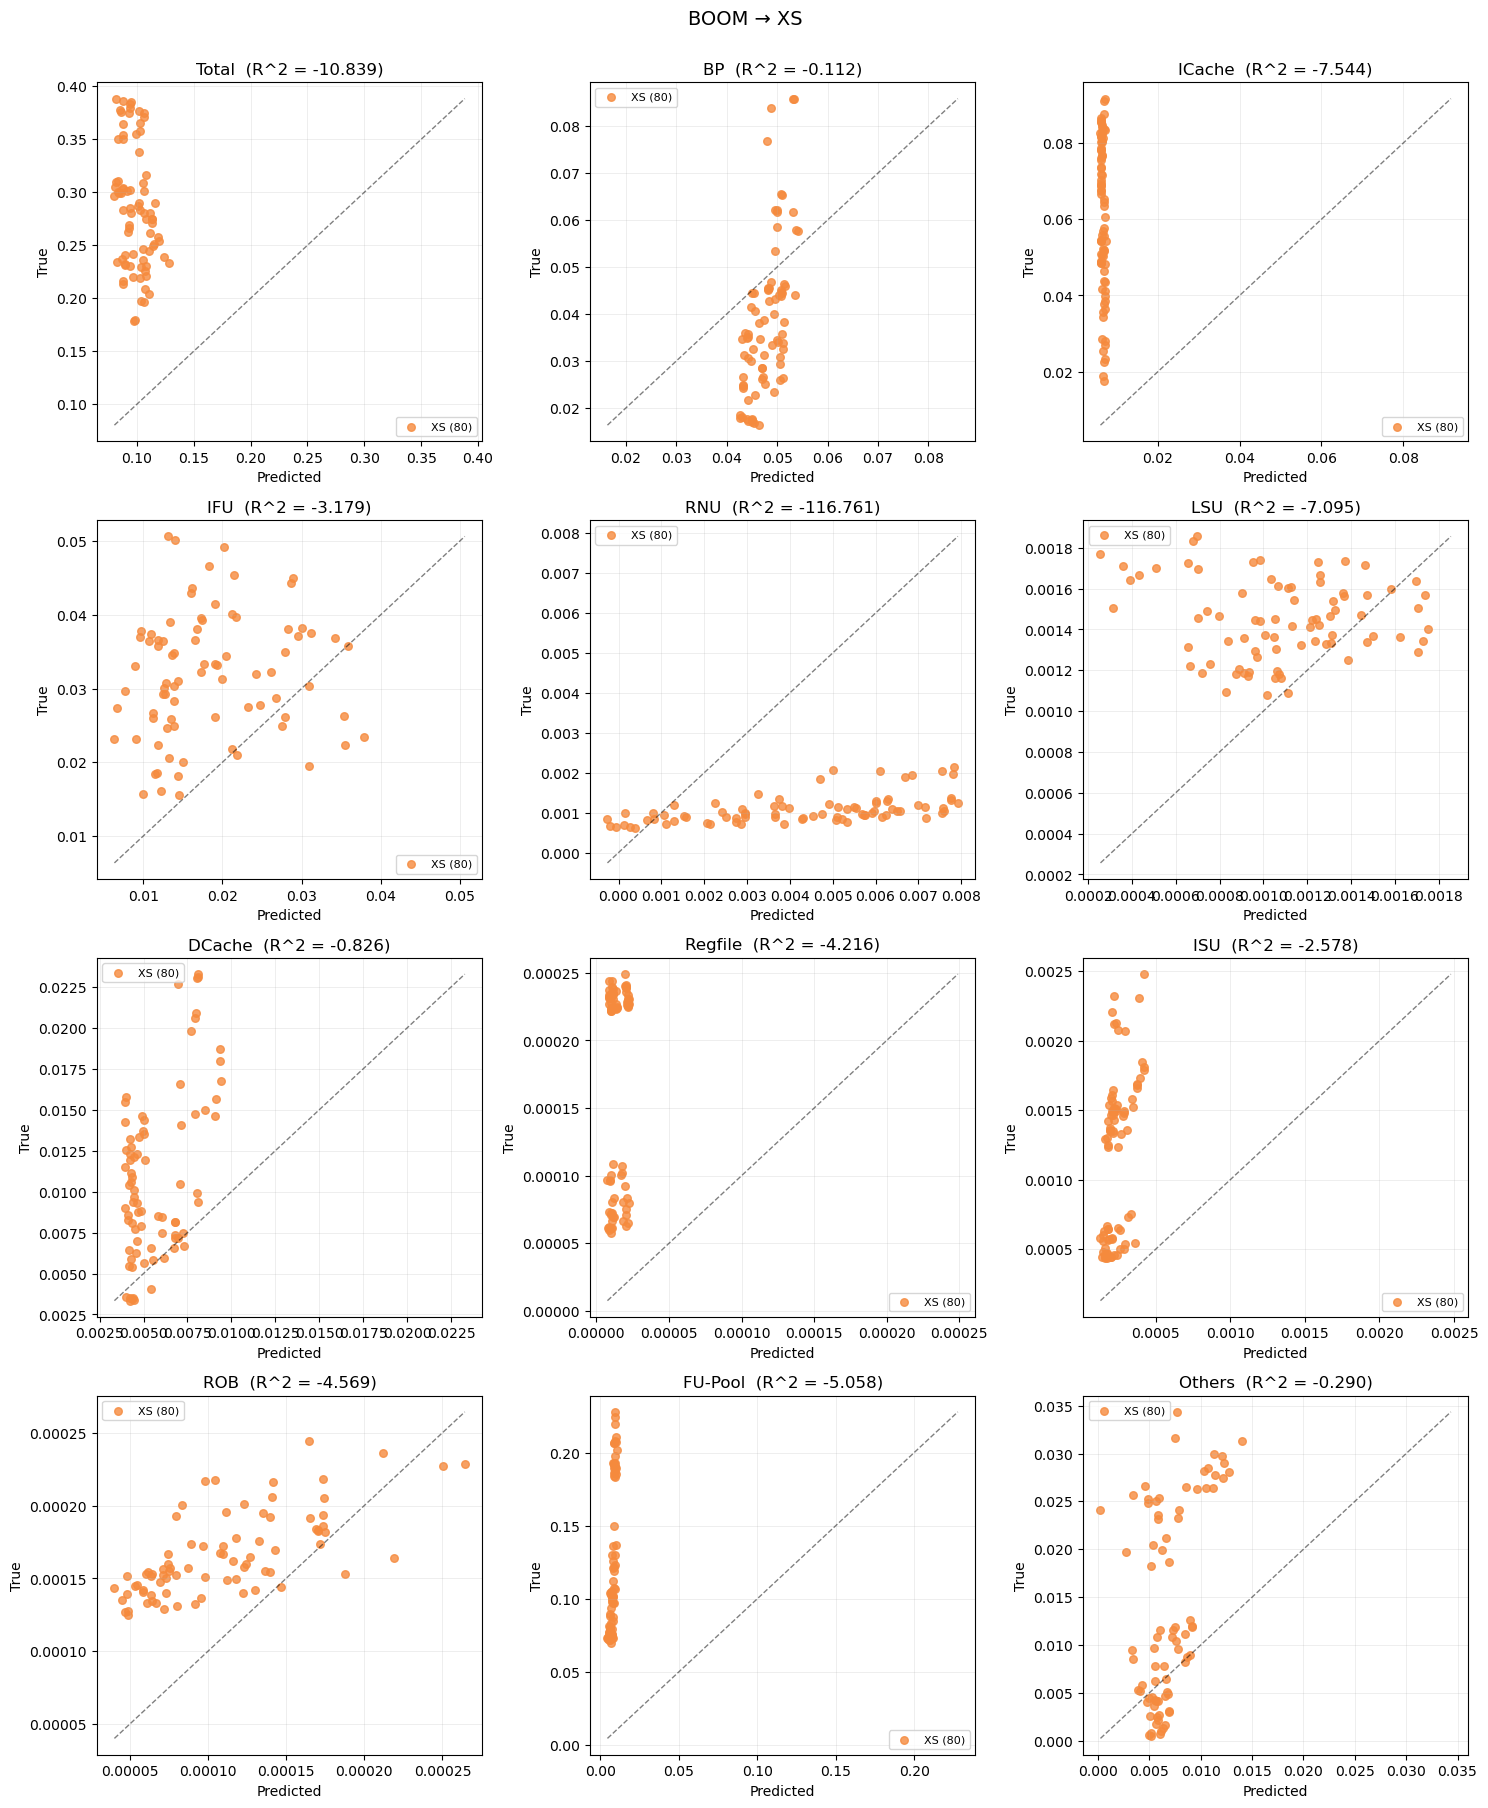

In [12]:
cross.plot_pred_vs_true(pred, true, metrics, TRAIN_ARCH, TEST_ARCH, OUT_DIR)
plt.show()

## 5. Generate markdown report

Writes the same `output/cross_<MODEL>_<TRAIN>_to_<TEST>/report.md` that `src/event_cross_arch.py` produces from the CLI.

In [7]:
cross.write_report(
    train_arch=TRAIN_ARCH,
    test_arch=TEST_ARCH,
    model_kind=MODEL_KIND,
    data=data,
    metrics=metrics,
    hyperparams=hyperparams,
    n_params=n_params,
    out_path=os.path.join(OUT_DIR, "report.md"),
)
print(f"\nDone! All outputs in: {os.path.abspath(OUT_DIR)}/")

  Report saved to ../output/cross_gbdt_BOOM_to_XS/report.md

Done! All outputs in: /Users/charlesjiang/Documents/github/ArchPower/output/cross_gbdt_BOOM_to_XS/
